In [1]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
import pandas as pd
import re
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD, PCA
from sentence_transformers import SentenceTransformer
from matplotlib import pyplot as plt
%matplotlib inline

In [3]:
path = "/content/drive/MyDrive/Projects/Haltgut/data/dataset.csv"
df = pd.read_csv(path)

### Remove Duplicates

In [4]:
def normalize_name(name: str) -> str:
    
    ### turn all characters into lower case
    name = str(name).lower()
    ### remove quantities "Banane 500g" -> "Banane"
    name = re.sub(r"\d+[,.]?\d*\s?(g|kg|ml|l|stk|stück|x)\b", " ", name)
    ### get rid of redundant spaces
    name = re.sub(r"\s+", " ", name).strip()
    
    return name

In [5]:
df["name_norm"] = df["product_name"].apply(normalize_name)

In [6]:
df["name_norm"].duplicated().sum()

np.int64(53959)

In [7]:
df = df.drop_duplicates(subset=["name_norm"])

### Check most frequent words per class

In [32]:
def most_common_words(series, n=50):
    counter = Counter()
    for text in series:
        counter.update(str(text).split())
    return counter.most_common(n)

In [34]:
food_words = most_common_words(df[df["edible"] == True]["name_norm"])
non_food_words = most_common_words(df[df["edible"] == False]["name_norm"])

<BarContainer object of 15 artists>

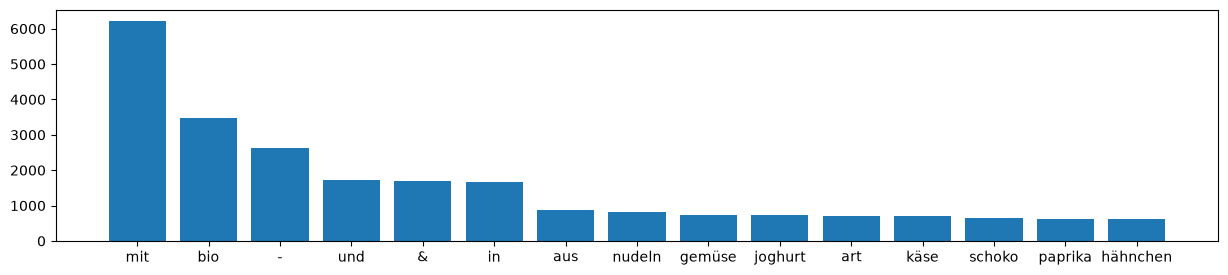

In [51]:
plt.figure(figsize=(15, 3))
plt.bar([w[0] for w in food_words[:15]], [w[1] for w in food_words[:15]])

<BarContainer object of 15 artists>

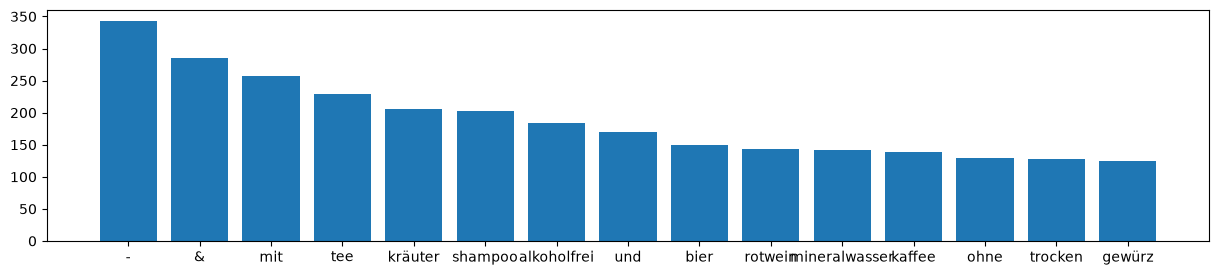

In [52]:
plt.figure(figsize=(15, 3))
plt.bar([w[0] for w in non_food_words[:15]], [w[1] for w in non_food_words[:15]])

### Length of words by class

In [44]:
df.groupby("edible")[["name_len", "token_count"]].describe()

name_len                                                      \
          count       mean        std  min   25%   50%   75%    max   
edible                                                                
False   15376.0  19.067443  10.729038  2.0  13.0  17.0  23.0  324.0   
True    71572.0  23.692058  11.978720  3.0  16.0  21.0  28.0  442.0   

       token_count                                                
             count      mean       std  min  25%  50%  75%   max  
edible                                                            
False      15376.0  2.384495  1.486478  1.0  1.0  2.0  3.0  41.0  
True       71572.0  2.842899  1.668976  1.0  2.0  3.0  3.0  51.0

### Embed words to vectors

In [12]:
texts = df["name_norm"]
labels = df["edible"]

In [9]:
vectorizer = TfidfVectorizer(
    analyzer="char_wb",
    ngram_range=(3, 5),
    min_df=5
)

In [10]:
X = vectorizer.fit_transform(texts)

In [11]:
svd = TruncatedSVD(n_components=2, random_state=42)
X_2d = svd.fit_transform(X)

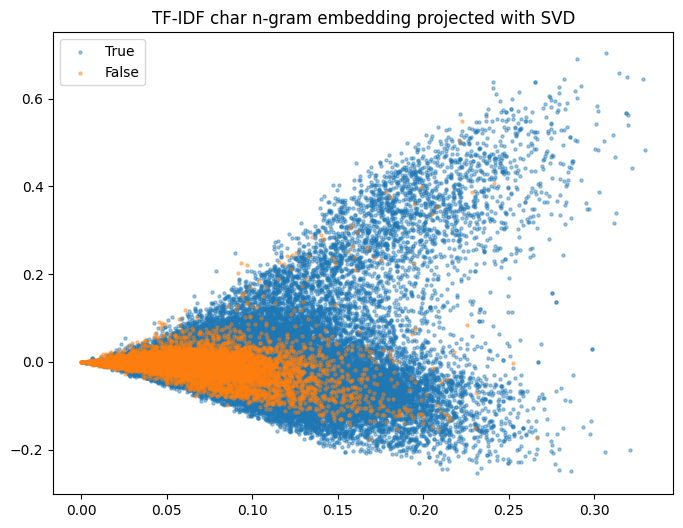

In [12]:
plt.figure(figsize=(8, 6))

for label in labels.unique():
    idx = labels == label
    plt.scatter(X_2d[idx, 0], X_2d[idx, 1], s=5, alpha=0.4, label=label)

plt.legend()
plt.title("TF-IDF char n-gram embedding projected with SVD")
plt.show()

In [8]:
model = SentenceTransformer(
    "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2",
    device="cuda"
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:122: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/3.89k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/526 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [9]:
texts = df["name_norm"].fillna("").tolist()
embeddings = model.encode(texts, batch_size=64, show_progress_bar=True)

Batches:   0%|          | 0/1359 [00:00<?, ?it/s]

In [10]:
pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(embeddings)

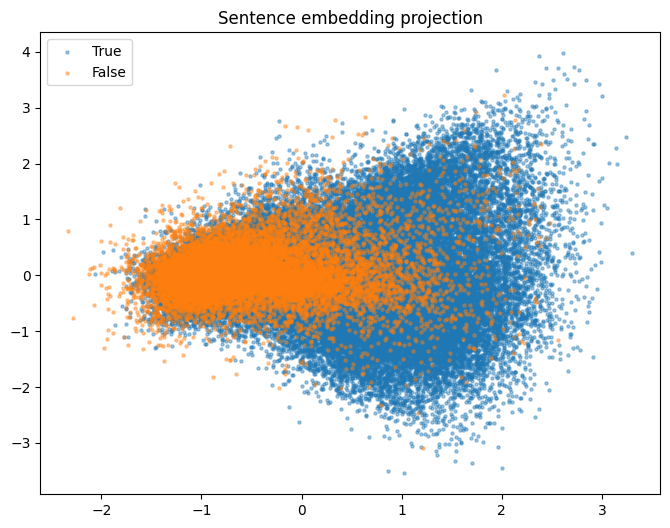

In [16]:
plt.figure(figsize=(8, 6))

for label in labels.unique():
    idx = df["edible"] == label
    plt.scatter(X_2d[idx, 0], X_2d[idx, 1], s=5, alpha=0.4, label=label)

plt.legend()
plt.title("Sentence embedding projection")
plt.show()